In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
# Class 0
X0 = torch.randn(50, 2) + torch.tensor([-2., -2.])

# Class 1
X1 = torch.randn(50, 2) + torch.tensor([2., 2.])

# Combine
X = torch.cat([X0, X1], dim=0)

y = torch.cat([
    torch.zeros(50, dtype=torch.long),
    torch.ones(50, dtype=torch.long)
])

print(X.shape)
print(y.shape)

torch.Size([100, 2])
torch.Size([100])


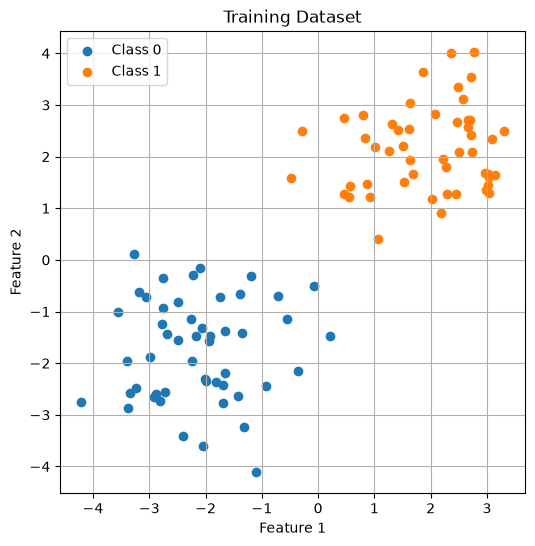

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(X0[:,0], X0[:,1], label="Class 0")
plt.scatter(X1[:,0], X1[:,1], label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Dataset")

plt.grid(True)
plt.legend()
plt.show()

In [4]:
def entropy(labels):

    if len(labels) == 0:
        return 0

    classes, counts = torch.unique(labels,return_counts=True)

    probabilities = counts.float() / len(labels)

    entropy_value = -(probabilities * torch.log2(probabilities)).sum()

    return entropy_value.item()

In [5]:
print(entropy(torch.tensor([0,0,0,0])))
print(entropy(torch.tensor([0,1,0,1])))

-0.0
1.0


In [6]:
def information_gain(X, y, feature, threshold):

    parent_entropy = entropy(y)

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left_labels = y[left_mask]
    right_labels = y[right_mask]

    if len(left_labels) == 0 or len(right_labels) == 0:
        return 0

    left_weight = len(left_labels) / len(y)
    right_weight = len(right_labels) / len(y)

    child_entropy = (left_weight * entropy(left_labels) + right_weight * entropy(right_labels))

    return parent_entropy - child_entropy


In [7]:
def best_split(X, y):

    best_gain = -1

    best_feature = None
    best_threshold = None

    num_features = X.shape[1]

    for feature in range(num_features):

        thresholds = torch.unique(X[:, feature])

        for threshold in thresholds:

            gain = information_gain(
                X,
                y,
                feature,
                threshold.item()
            )

            if gain > best_gain:

                best_gain = gain
                best_feature = feature
                best_threshold = threshold.item()

    return best_feature, best_threshold

In [8]:
class Node:

    def __init__(self,feature=None,threshold=None,left=None,right=None,value=None):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

In [9]:
def build_tree(X, y, depth=0, max_depth=3):

    # Pure node
    if len(torch.unique(y)) == 1:

        return Node(value=y[0].item())

    # Maximum depth reached
    if depth >= max_depth:

        majority = torch.mode(y).values.item()
        return Node(value=majority)

    feature, threshold = best_split(X, y)

    if feature is None:

        majority = torch.mode(y).values.item()
        return Node(value=majority)

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left = build_tree( X[left_mask],y[left_mask],depth + 1,max_depth)

    right = build_tree(X[right_mask],y[right_mask],depth + 1,max_depth)

    return Node(feature=feature,threshold=threshold,left=left,right=right)

In [10]:
tree = build_tree(X, y)

In [11]:
def bootstrap_sample(X, y):

    n_samples = len(X)

    indices = torch.randint( 0, n_samples, (n_samples,))

    return X[indices], y[indices]

In [12]:
class RandomForest:

    def __init__(self,n_trees=10,max_depth=3):

        self.n_trees = n_trees
        self.max_depth = max_depth

        self.trees = []

    def fit(self, X, y):

        self.trees = []

        for _ in range(self.n_trees):

            X_sample, y_sample = bootstrap_sample(X, y)

            tree = build_tree(
                X_sample,
                y_sample,
                max_depth=self.max_depth
            )

            self.trees.append(tree)

In [13]:
def predict_tree(x, node):

    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:

        return predict_tree(x, node.left)

    return predict_tree(x, node.right)

In [14]:
def predict(self, X):

    all_predictions = []

    for tree in self.trees:

        predictions = []

        for sample in X:

            predictions.append(predict_tree(sample, tree))

        all_predictions.append(torch.tensor(predictions))

    all_predictions = torch.stack(all_predictions)

    final_predictions = []

    for column in all_predictions.T:

        vote = torch.mode(column).values
        final_predictions.append(vote)

    return torch.stack(final_predictions)

RandomForest.predict = predict

In [15]:
forest = RandomForest(n_trees=20,max_depth=4)

forest.fit(X, y)

In [16]:
predictions = forest.predict(X)

accuracy = (
    predictions == y
).float().mean()

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 100.00%


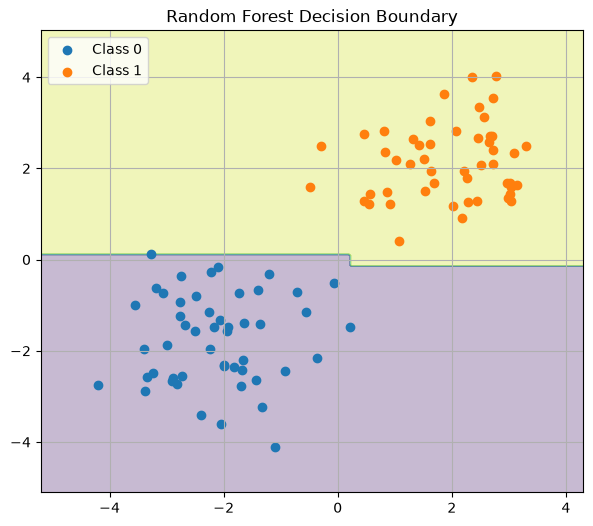

In [17]:
x_min = X[:,0].min() - 1
x_max = X[:,0].max() + 1

y_min = X[:,1].min() - 1
y_max = X[:,1].max() + 1

xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 200),
    torch.linspace(y_min, y_max, 200),
    indexing="ij"
)

grid = torch.stack(
    [xx.reshape(-1), yy.reshape(-1)],
    dim=1
)

grid_predictions = forest.predict(grid)
grid_predictions = grid_predictions.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(
    xx.numpy(),
    yy.numpy(),
    grid_predictions.numpy(),
    alpha=0.3
)

plt.scatter(
    X0[:,0],
    X0[:,1],
    label="Class 0"
)

plt.scatter(
    X1[:,0],
    X1[:,1],
    label="Class 1"
)

plt.legend()
plt.grid(True)
plt.title("Random Forest Decision Boundary")

plt.show()